# NB-04 · DINOv2 + DeepLabV3 for Brain Tumour MRI Semantic Segmentation

**Course:** CSE 438: Digital Image Processing  
**Instructor:** Dr Md Rifat Ahmmad Rashid  
**Department:** Department of Computer Science and Engineering  
**Institution:** East West University (EWU)

---

## Notebook objective

This notebook develops a binary semantic-segmentation pipeline for brain tumour MRI images stored in **COCO polygon format**:

\[
0=\text{background}, \qquad 1=\text{tumour region}.
\]

The model combines:

- a **DINOv2 ViT-S/14 encoder**, which provides self-supervised visual representations;
- a **DeepLabV3-style Atrous Spatial Pyramid Pooling (ASPP) head**, which predicts the tumour mask from the spatial DINOv2 token map.

The combination is methodologically direct: DINOv2 patch tokens are reshaped into a 2-D feature grid and supplied to ASPP. The notebook does **not** train an unrelated ResNet encoder and does **not** describe a ResNet checkpoint as DINOv2 transfer learning.

### Learning outcomes

After completing this notebook, students should be able to:

1. convert COCO polygon annotations into merged binary semantic masks;
2. explain how a ViT patch-token sequence becomes a spatial feature map;
3. relate atrous convolution and ASPP to multi-scale tumour localisation;
4. apply transfer learning using a self-supervised visual backbone;
5. interpret probability maps, overlay images, error maps, response maps, and t-SNE feature plots.

### Principal references

- Oquab *et al.* (2023), *DINOv2: Learning Robust Visual Features without Supervision*, arXiv:2304.07193.
- Chen *et al.* (2017), *Rethinking Atrous Convolution for Semantic Image Segmentation*, arXiv:1706.05587.
- Hugging Face Transformers documentation: `Dinov2Model` and the checkpoint `facebook/dinov2-small`.

> **Kaggle note:** Pretrained DINOv2 weights require either Kaggle Internet access or a cached model. If neither is available, the notebook creates the same DINOv2-small architecture with random initialisation so that the computational pipeline remains executable. Such a fallback is a diagnostic run, not pretrained DINOv2 transfer learning.

## 1. Experimental configuration and imports

The dataset path below is fixed for this laboratory notebook. All generated figures, checkpoints, and metric tables are saved under `/kaggle/working/dinov2_deeplabv3_brain_tumour`.

In [1]:
# Standard library imports
import os
import gc
import json
import math
import random
import copy
from contextlib import nullcontext
from pathlib import Path
from collections import defaultdict

# Numerical and visualisation libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from PIL import Image, ImageDraw

# PyTorch and model libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torchvision.transforms import ColorJitter
from torchvision.transforms.functional import InterpolationMode
from transformers import Dinov2Model, Dinov2Config

# Evaluation and dimensionality reduction
from sklearn.manifold import TSNE
from tqdm.auto import tqdm

# ---------------------------------------------------------------------------
# Dataset and output locations
# ---------------------------------------------------------------------------
DATA_ROOT = Path("/kaggle/input/datasets/pkdarabi/brain-tumor-image-dataset-semantic-segmentation")
OUTPUT_DIR = Path("/kaggle/working/dinov2_deeplabv3_brain_tumour")
FIGURE_DIR = OUTPUT_DIR / "figures"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# Reproducibility and experiment hyperparameters
# ---------------------------------------------------------------------------
SEED = 438
IMG_SIZE = 224                   # 224 / 14 = 16 patches along each axis for ViT-S/14
NUM_CLASSES = 2                  # background and tumour
EPOCHS = 10
WARMUP_EPOCHS = 2                # train ASPP head first, then fine-tune DINOv2 encoder
HEAD_LR = 2e-4
ENCODER_LR = 1e-5
WEIGHT_DECAY = 1e-4
DICE_WEIGHT = 0.70
MODEL_NAME = "facebook/dinov2-small"

def seed_everything(seed: int = SEED) -> None:
    """Set deterministic seeds where practical for classroom reproducibility."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything()
print(f"Outputs will be written to: {OUTPUT_DIR}")

Outputs will be written to: /kaggle/working/dinov2_deeplabv3_brain_tumour


## 2. CUDA compatibility probe and AMP policy

A visible CUDA device is not sufficient evidence that kernel execution will work in a Kaggle session. The following probe performs a small convolution, reduction, and backward pass **before model training**. Automatic mixed precision (AMP) is enabled only if this kernel test succeeds.

No executable `channels_last` conversions are used; tensors retain their ordinary contiguous memory format.

In [2]:
def select_safe_device():
    """
    Select CUDA only after a kernel-execution test.
    This prevents training from failing later with incompatible CUDA kernels.
    """
    if not torch.cuda.is_available():
        print("CUDA is not reported as available. Using CPU; AMP is disabled.")
        return torch.device("cpu"), False

    try:
        probe_input = torch.randn(2, 3, 32, 32, device="cuda", requires_grad=True)
        probe_layer = nn.Conv2d(3, 4, kernel_size=3, padding=1).to("cuda")
        probe_loss = probe_layer(probe_input).square().mean()
        probe_loss.backward()
        torch.cuda.synchronize()
        del probe_input, probe_layer, probe_loss
        torch.cuda.empty_cache()
        print(f"CUDA kernel probe passed: {torch.cuda.get_device_name(0)}")
        print("AMP will be enabled for model forward passes.")
        return torch.device("cuda"), True
    except Exception as exc:
        print("CUDA is visible but failed the compatibility probe.")
        print(f"Diagnostic: {type(exc).__name__}: {str(exc)[:240]}")
        print("Falling back to CPU; AMP is disabled.")
        try:
            torch.cuda.empty_cache()
        except Exception:
            pass
        return torch.device("cpu"), False

device, AMP_ENABLED = select_safe_device()
BATCH_SIZE = 8 if device.type == "cuda" else 2
NUM_WORKERS = 2 if device.type == "cuda" else 0
PIN_MEMORY = device.type == "cuda"

def amp_context():
    """Use float16 autocasting only when the CUDA probe has succeeded."""
    if AMP_ENABLED:
        return torch.autocast(device_type="cuda", dtype=torch.float16)
    return nullcontext()

try:
    scaler = torch.amp.GradScaler("cuda", enabled=AMP_ENABLED)
except (AttributeError, TypeError):
    scaler = torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

print(f"Selected device: {device} | AMP enabled: {AMP_ENABLED} | Batch size: {BATCH_SIZE}")

CUDA kernel probe passed: Tesla T4
AMP will be enabled for model forward passes.
Selected device: cuda | AMP enabled: True | Batch size: 8


## 3. COCO polygons to binary semantic masks

Each MRI image may contain one or more polygon annotations. Object instances are not treated as separate output categories in this experiment. Instead, every tumour polygon is drawn into one common mask, thereby merging overlaps and multiple regions into a binary tumour target.

In [3]:
# ---------------------------------------------------------------------------
# COCO annotation reader and polygon rasterisation
# ---------------------------------------------------------------------------
def read_coco_split(split_dir: Path):
    """Read one COCO split and group all annotations by image identifier."""
    annotation_path = split_dir / "_annotations.coco.json"
    if not annotation_path.exists():
        raise FileNotFoundError(f"Missing annotation file: {annotation_path}")

    with open(annotation_path, "r", encoding="utf-8") as file:
        coco = json.load(file)

    annotations_by_image = defaultdict(list)
    for annotation in coco.get("annotations", []):
        annotations_by_image[annotation["image_id"]].append(annotation)

    image_records = []
    for image_info in coco.get("images", []):
        image_path = split_dir / image_info["file_name"]
        if image_path.exists():
            image_records.append(image_info)
        else:
            print(f"Warning: image listed in JSON was not found: {image_path}")

    return image_records, annotations_by_image


def polygons_to_binary_mask(image_info: dict, annotations: list) -> Image.Image:
    """
    Merge all COCO polygon components for one image into a single binary mask.
    The returned PIL image uses values 0 and 1, rather than 0 and 255.
    """
    width, height = int(image_info["width"]), int(image_info["height"])
    mask = Image.new("L", (width, height), color=0)
    drawer = ImageDraw.Draw(mask)

    for annotation in annotations:
        segmentation = annotation.get("segmentation", [])
        if not isinstance(segmentation, list):
            raise ValueError(
                "This notebook expects COCO polygon segmentation. "
                "An RLE annotation was encountered."
            )

        for polygon in segmentation:
            if len(polygon) >= 6:  # At least three coordinate pairs.
                xy = [(polygon[i], polygon[i + 1]) for i in range(0, len(polygon), 2)]
                drawer.polygon(xy, outline=1, fill=1)

    return mask


class BrainTumourCocoDataset(Dataset):
    """MRI image and merged binary semantic-mask dataset."""

    def __init__(self, split_dir: Path, image_size: int = IMG_SIZE, training: bool = False):
        self.split_dir = split_dir
        self.image_size = image_size
        self.training = training
        self.images, self.annotations_by_image = read_coco_split(split_dir)
        self.intensity_jitter = ColorJitter(brightness=0.10, contrast=0.10)
        self.mean = [0.485, 0.456, 0.406]
        self.std = [0.229, 0.224, 0.225]

    def __len__(self):
        return len(self.images)

    def load_raw_pair(self, index: int):
        image_info = self.images[index]
        image = Image.open(self.split_dir / image_info["file_name"]).convert("RGB")
        mask = polygons_to_binary_mask(
            image_info, self.annotations_by_image.get(image_info["id"], [])
        )
        return image, mask

    def __getitem__(self, index: int):
        image, mask = self.load_raw_pair(index)
        image = TF.resize(image, [self.image_size, self.image_size], interpolation=InterpolationMode.BILINEAR)
        mask = TF.resize(mask, [self.image_size, self.image_size], interpolation=InterpolationMode.NEAREST)

        if self.training:
            if random.random() < 0.5:
                image = TF.hflip(image)
                mask = TF.hflip(mask)

            if random.random() < 0.35:
                angle = random.uniform(-10.0, 10.0)
                image = TF.rotate(image, angle, interpolation=InterpolationMode.BILINEAR, fill=0)
                mask = TF.rotate(mask, angle, interpolation=InterpolationMode.NEAREST, fill=0)

            image = self.intensity_jitter(image)

        image_tensor = TF.normalize(TF.to_tensor(image), mean=self.mean, std=self.std)
        mask_tensor = torch.from_numpy(np.array(mask, dtype=np.int64))
        mask_tensor = (mask_tensor > 0).long()
        return image_tensor.contiguous(), mask_tensor.contiguous()

In [4]:
# ---------------------------------------------------------------------------
# Construct train, validation, and test datasets/loaders
# ---------------------------------------------------------------------------
train_dataset = BrainTumourCocoDataset(DATA_ROOT / "train", training=True)
valid_dataset = BrainTumourCocoDataset(DATA_ROOT / "valid", training=False)
test_dataset = BrainTumourCocoDataset(DATA_ROOT / "test", training=False)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY, drop_last=False
)
valid_loader = DataLoader(
    valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY, drop_last=False
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY, drop_last=False
)

split_table = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Images": [len(train_dataset), len(valid_dataset), len(test_dataset)]
})
display(split_table)

,Split,Images
0,Train,1502
1,Validation,429
2,Test,215


## 4. Dataset inspection: tumour-area distribution and annotation overlay

Tumour segmentation is typically imbalanced because the foreground region occupies only a small part of an MRI slice. Accuracy alone can therefore be misleading: a background-heavy prediction may obtain high pixel accuracy while missing the relevant region. Dice and IoU will be reported alongside accuracy.

Measuring train masks:   0%|          | 0/1502 [00:00<?, ?it/s]

Measuring valid masks:   0%|          | 0/429 [00:00<?, ?it/s]

Measuring test masks:   0%|          | 0/215 [00:00<?, ?it/s]

,Split,Images,Images with tumour mask,Mean tumour area (%)
0,Train,1502,1501,3.711
1,Validation,429,429,3.723
2,Test,215,215,3.711


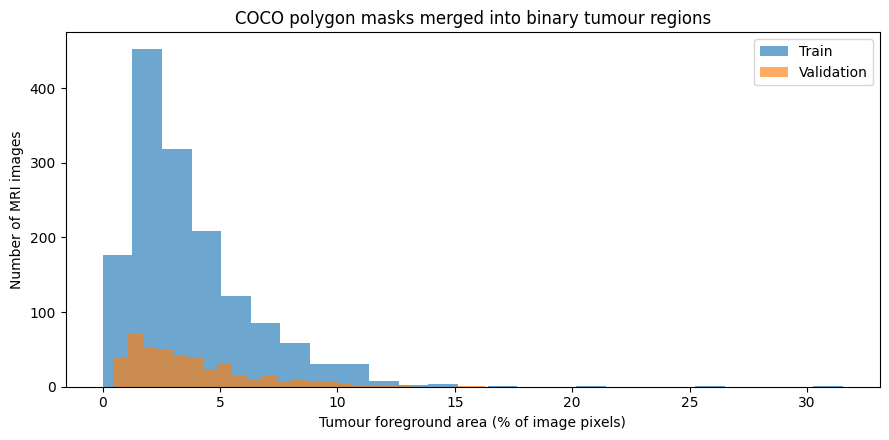

In [5]:
def mask_area_statistics(dataset: BrainTumourCocoDataset):
    """Measure the foreground fraction in each original annotation mask."""
    fractions = []
    for index in tqdm(range(len(dataset)), desc=f"Measuring {dataset.split_dir.name} masks"):
        _, mask = dataset.load_raw_pair(index)
        mask_np = np.array(mask, dtype=np.float32)
        fractions.append(mask_np.mean())
    return np.asarray(fractions)

train_fractions = mask_area_statistics(train_dataset)
valid_fractions = mask_area_statistics(valid_dataset)
test_fractions = mask_area_statistics(test_dataset)

area_summary = pd.DataFrame({
    "Split": ["Train", "Validation", "Test"],
    "Images": [len(train_fractions), len(valid_fractions), len(test_fractions)],
    "Images with tumour mask": [
        int((train_fractions > 0).sum()),
        int((valid_fractions > 0).sum()),
        int((test_fractions > 0).sum())
    ],
    "Mean tumour area (%)": [
        100 * train_fractions.mean(), 100 * valid_fractions.mean(), 100 * test_fractions.mean()
    ]
})
display(area_summary.round(3))

plt.figure(figsize=(9, 4.5))
plt.hist(100 * train_fractions, bins=25, alpha=0.65, label="Train")
plt.hist(100 * valid_fractions, bins=25, alpha=0.65, label="Validation")
plt.xlabel("Tumour foreground area (% of image pixels)")
plt.ylabel("Number of MRI images")
plt.title("COCO polygon masks merged into binary tumour regions")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "mask_area_distribution.png", dpi=220)
plt.show()

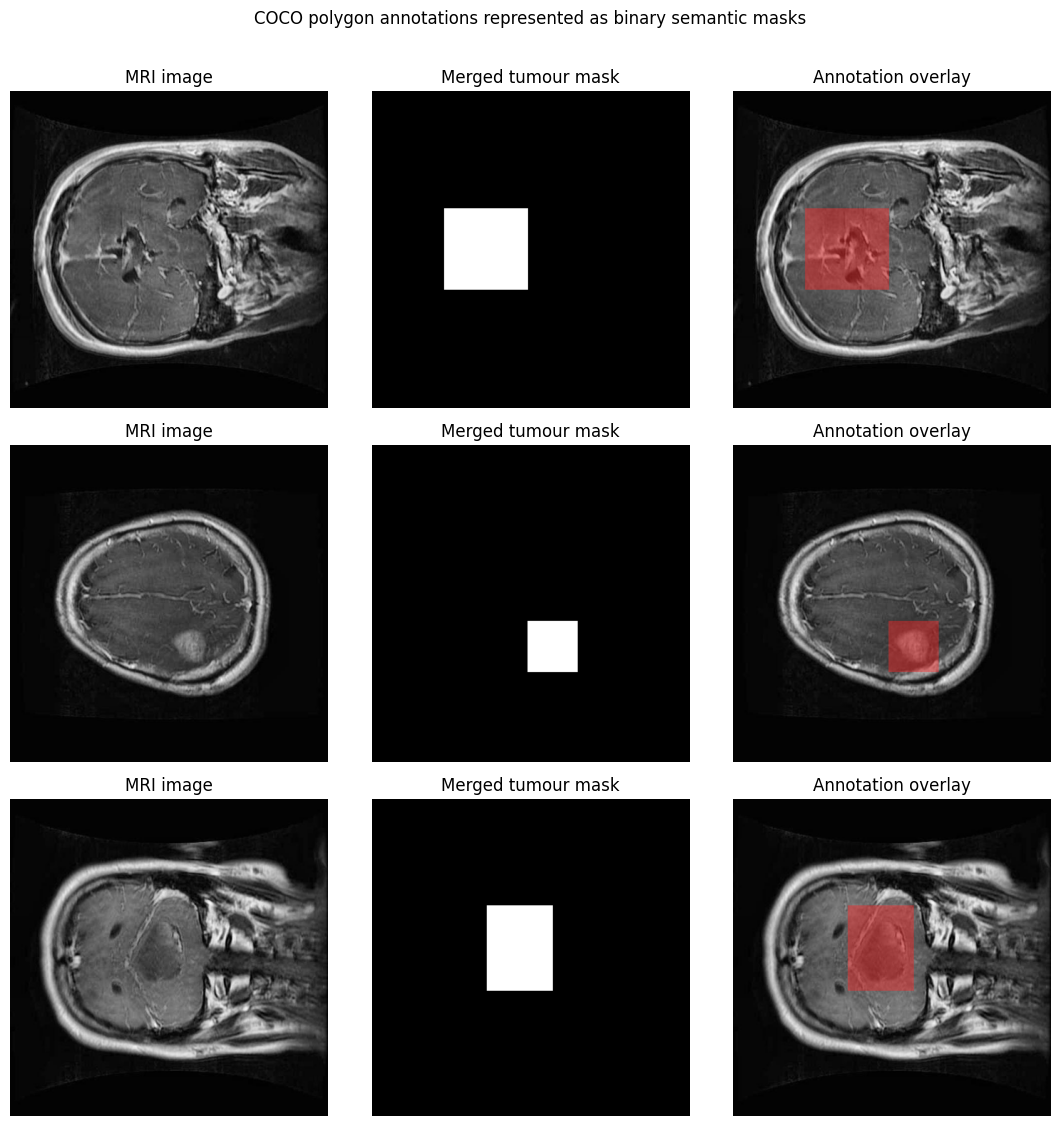

In [6]:
def show_annotation_examples(dataset: BrainTumourCocoDataset, fractions: np.ndarray, count: int = 3):
    """Show images with visible tumour annotations and their overlay masks."""
    candidate_indices = np.where(fractions > 0)[0]
    if len(candidate_indices) == 0:
        candidate_indices = np.arange(min(count, len(dataset)))
    selected = candidate_indices[
        np.linspace(0, len(candidate_indices) - 1, min(count, len(candidate_indices)), dtype=int)
    ]

    fig, axes = plt.subplots(len(selected), 3, figsize=(11, 3.7 * len(selected)))
    axes = np.atleast_2d(axes)

    for row, index in enumerate(selected):
        image, mask = dataset.load_raw_pair(int(index))
        image_np = np.array(image)
        mask_np = np.array(mask)

        overlay = image_np.copy()
        overlay[mask_np > 0] = (
            0.55 * overlay[mask_np > 0] + 0.45 * np.array([255, 40, 40])
        )

        axes[row, 0].imshow(image_np)
        axes[row, 0].set_title("MRI image")
        axes[row, 1].imshow(mask_np, cmap="gray", vmin=0, vmax=1)
        axes[row, 1].set_title("Merged tumour mask")
        axes[row, 2].imshow(overlay.astype(np.uint8))
        axes[row, 2].set_title("Annotation overlay")

        for axis in axes[row]:
            axis.axis("off")

    plt.suptitle("COCO polygon annotations represented as binary semantic masks", y=1.01)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "annotation_examples.png", dpi=220, bbox_inches="tight")
    plt.show()

show_annotation_examples(train_dataset, train_fractions)

## 5. DINOv2 + DeepLabV3 modelling principle

DINOv2 ViT-S/14 splits a \(224\times224\) MRI image into \(14\times14\) patches, producing a \(16\times16\) grid of patch tokens. Removing the class token and reshaping the remaining tokens restores a spatial feature tensor:

\[
(B, 256, C) \longrightarrow (B, C, 16, 16).
\]

The DeepLabV3-style ASPP head then samples this token-derived feature grid with parallel atrous convolutions and a global pooling branch. Because the incoming grid is smaller than a conventional convolutional backbone feature map, moderate dilation rates are used in this instructional model: \(3,6,9\).

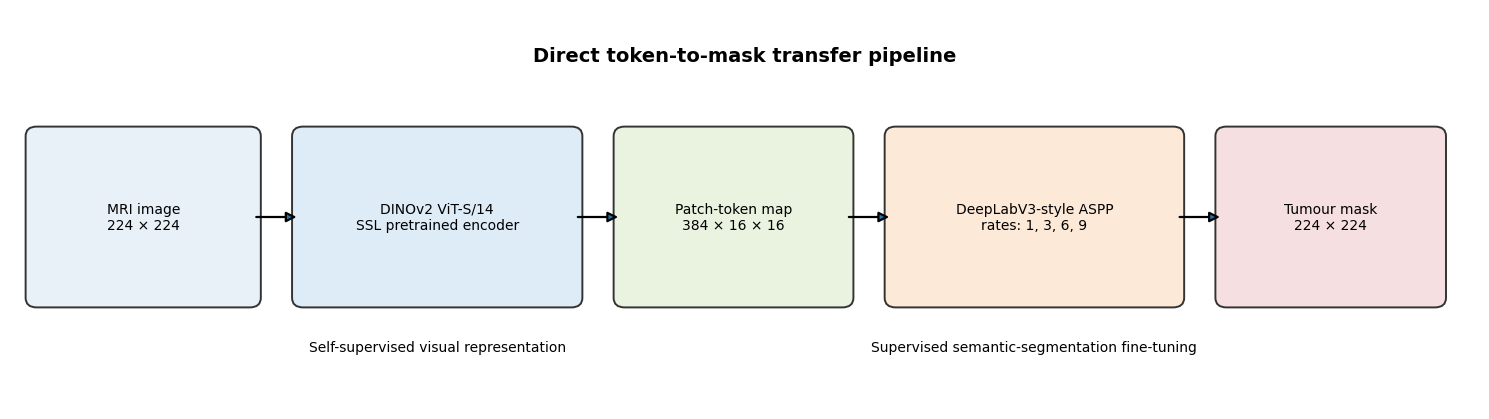

In [7]:
def draw_workflow_diagram():
    """Create an instructional architecture diagram without external assets."""
    fig, ax = plt.subplots(figsize=(15, 4.3))
    ax.set_xlim(0, 16)
    ax.set_ylim(0, 5)
    ax.axis("off")

    stages = [
        (0.25, 1.35, 2.4, 2.1, "MRI image\n224 × 224", "#E8F1F8"),
        (3.15, 1.35, 3.0, 2.1, "DINOv2 ViT-S/14\nSSL pretrained encoder", "#DDECF7"),
        (6.65, 1.35, 2.45, 2.1, "Patch-token map\n384 × 16 × 16", "#EAF3DF"),
        (9.60, 1.35, 3.1, 2.1, "DeepLabV3-style ASPP\nrates: 1, 3, 6, 9", "#FCE9D8"),
        (13.20, 1.35, 2.35, 2.1, "Tumour mask\n224 × 224", "#F6DFE1"),
    ]

    for x, y, width, height, text, colour in stages:
        box = FancyBboxPatch(
            (x, y), width, height, boxstyle="round,pad=0.08,rounding_size=0.12",
            linewidth=1.4, edgecolor="#333333", facecolor=colour
        )
        ax.add_patch(box)
        ax.text(x + width / 2, y + height / 2, text, ha="center", va="center", fontsize=10)

    for left, right in [(2.65, 3.15), (6.15, 6.65), (9.10, 9.60), (12.70, 13.20)]:
        ax.add_patch(FancyArrowPatch(
            (left, 2.4), (right, 2.4), arrowstyle="-|>",
            mutation_scale=15, linewidth=1.6
        ))

    ax.text(8.0, 4.35, "Direct token-to-mask transfer pipeline", ha="center",
            fontsize=14, fontweight="bold")
    ax.text(4.65, 0.72, "Self-supervised visual representation", ha="center", fontsize=10)
    ax.text(11.15, 0.72, "Supervised semantic-segmentation fine-tuning", ha="center", fontsize=10)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "dinov2_deeplabv3_workflow.png", dpi=220, bbox_inches="tight")
    plt.show()

draw_workflow_diagram()

## 6. Model definition: DINOv2 encoder and DeepLabV3-style ASPP segmentation head

The `load_dinov2_encoder` function first checks for locally cached pretrained weights, then tries online retrieval. A random-initialised fallback is included only to keep the notebook executable when a Kaggle session cannot access model files.

In [8]:
def build_random_dinov2_small():
    """Construct the DINOv2-small architecture without downloading weights."""
    configuration = Dinov2Config(
        image_size=IMG_SIZE,
        patch_size=14,
        num_channels=3,
        hidden_size=384,
        num_hidden_layers=12,
        num_attention_heads=6,
        intermediate_size=1536,
        hidden_act="gelu",
        layer_norm_eps=1e-6,
    )
    return Dinov2Model(configuration)


def load_dinov2_encoder(model_name: str = MODEL_NAME):
    """
    Prefer pretrained DINOv2 SSL weights. Fall back to architecture-only execution
    when the Kaggle runtime has neither cached files nor Internet connectivity.
    """
    try:
        encoder = Dinov2Model.from_pretrained(model_name, local_files_only=True)
        load_status = "Pretrained DINOv2 weights loaded from the Kaggle/Hugging Face cache."
    except Exception:
        try:
            encoder = Dinov2Model.from_pretrained(model_name)
            load_status = "Pretrained DINOv2 weights downloaded successfully."
        except Exception as exc:
            encoder = build_random_dinov2_small()
            load_status = (
                "Pretrained DINOv2 weights were unavailable. "
                "Using random DINOv2-small initialisation for executable demonstration only. "
                f"Reason: {type(exc).__name__}: {str(exc)[:160]}"
            )

    print(load_status)
    return encoder, load_status


class ASPPConv(nn.Sequential):
    """One dilated-convolution branch in Atrous Spatial Pyramid Pooling."""
    def __init__(self, in_channels: int, out_channels: int, dilation: int):
        super().__init__(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=dilation,
                      dilation=dilation, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )


class ASPPPooling(nn.Sequential):
    """Image-level context branch used in DeepLabV3 ASPP."""
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
            nn.GroupNorm(32, out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        pooled = super().forward(x)
        return F.interpolate(pooled, size=x.shape[-2:], mode="bilinear", align_corners=False)


class DeepLabV3ASPP(nn.Module):
    """DeepLabV3-style parallel multi-scale context module."""
    def __init__(self, in_channels: int, out_channels: int = 256, rates=(3, 6, 9)):
        super().__init__()
        branches = [
            nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(inplace=True)
            )
        ]
        branches.extend([ASPPConv(in_channels, out_channels, rate) for rate in rates])
        branches.append(ASPPPooling(in_channels, out_channels))
        self.branches = nn.ModuleList(branches)

        self.project = nn.Sequential(
            nn.Conv2d(len(branches) * out_channels, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.10)
        )

    def forward(self, x):
        branch_features = [branch(x) for branch in self.branches]
        return self.project(torch.cat(branch_features, dim=1))


class DINOv2DeepLabV3(nn.Module):
    """
    A DINOv2 encoder feeding a DeepLabV3-style ASPP segmentation head.

    DINOv2 provides spatial patch tokens; ASPP produces semantic logits;
    bilinear upsampling restores the input mask resolution.
    """
    def __init__(self, encoder: Dinov2Model, num_classes: int = NUM_CLASSES):
        super().__init__()
        self.encoder = encoder
        feature_dim = int(self.encoder.config.hidden_size)
        self.aspp = DeepLabV3ASPP(feature_dim, out_channels=256, rates=(3, 6, 9))
        self.classifier = nn.Sequential(
            nn.Conv2d(256, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.10),
            nn.Conv2d(128, num_classes, kernel_size=1)
        )

    def token_feature_map(self, images):
        output = self.encoder(pixel_values=images)
        patch_tokens = output.last_hidden_state[:, 1:, :]  # Remove CLS token.

        number_of_patches = patch_tokens.shape[1]
        grid_size = int(math.sqrt(number_of_patches))
        if grid_size * grid_size != number_of_patches:
            raise RuntimeError("Patch tokens cannot be reshaped into a square spatial feature map.")

        features = patch_tokens.transpose(1, 2).reshape(
            images.shape[0], patch_tokens.shape[-1], grid_size, grid_size
        )
        return features.contiguous()

    def forward(self, images):
        spatial_features = self.token_feature_map(images)
        logits_low_resolution = self.classifier(self.aspp(spatial_features))
        logits = F.interpolate(
            logits_low_resolution, size=images.shape[-2:],
            mode="bilinear", align_corners=False
        )
        return logits

In [9]:
# ---------------------------------------------------------------------------
# Instantiate the encoder and preserve its initial response for comparison.
# ---------------------------------------------------------------------------
encoder, DINOV2_LOAD_STATUS = load_dinov2_encoder()
initial_encoder = copy.deepcopy(encoder).cpu().eval()

model = DINOv2DeepLabV3(encoder=encoder, num_classes=NUM_CLASSES).to(device)

# Head warm-up: do not alter SSL features during the first two epochs.
for parameter in model.encoder.parameters():
    parameter.requires_grad = False

optimizer = torch.optim.AdamW(
    [
        {"params": model.encoder.parameters(), "lr": ENCODER_LR},
        {"params": list(model.aspp.parameters()) + list(model.classifier.parameters()), "lr": HEAD_LR},
    ],
    weight_decay=WEIGHT_DECAY
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

trainable_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)
all_parameters = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {all_parameters:,}")
print(f"Initially trainable parameters during ASPP-head warm-up: {trainable_parameters:,}")
print(DINOV2_LOAD_STATUS)

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Pretrained DINOv2 weights downloaded successfully.
Model parameters: 25,533,570
Initially trainable parameters during ASPP-head warm-up: 3,476,994
Pretrained DINOv2 weights downloaded successfully.


## 7. Loss and segmentation metrics

The optimisation objective combines categorical cross-entropy with foreground Dice loss. Cross-entropy evaluates per-pixel class decisions, whereas Dice directly penalises disagreement in the relatively small tumour region. Validation and test reporting includes Dice, intersection-over-union (IoU), and pixel accuracy.

In [10]:
def foreground_dice_loss(logits: torch.Tensor, targets: torch.Tensor, epsilon: float = 1e-6):
    """Soft Dice loss calculated for the tumour foreground class only."""
    probabilities = torch.softmax(logits.float(), dim=1)[:, 1]
    foreground = (targets == 1).float()

    intersection = (probabilities * foreground).sum(dim=(1, 2))
    denominator = probabilities.sum(dim=(1, 2)) + foreground.sum(dim=(1, 2))
    dice = (2.0 * intersection + epsilon) / (denominator + epsilon)
    return 1.0 - dice.mean()


def segmentation_loss(logits: torch.Tensor, targets: torch.Tensor):
    """Stable float32 objective; model forward passes may still use AMP."""
    logits_float = logits.float()
    ce_loss = F.cross_entropy(logits_float, targets)
    dice_loss = foreground_dice_loss(logits_float, targets)
    total_loss = ce_loss + DICE_WEIGHT * dice_loss
    return total_loss, ce_loss.detach(), dice_loss.detach()


def segmentation_counts(logits: torch.Tensor, targets: torch.Tensor):
    """Accumulate hard prediction counts for binary tumour metrics."""
    predictions = torch.argmax(logits, dim=1)
    foreground_prediction = predictions == 1
    foreground_target = targets == 1

    tp = (foreground_prediction & foreground_target).sum().item()
    fp = (foreground_prediction & ~foreground_target).sum().item()
    fn = (~foreground_prediction & foreground_target).sum().item()
    correct = (predictions == targets).sum().item()
    pixels = targets.numel()
    return tp, fp, fn, correct, pixels


def metrics_from_counts(tp, fp, fn, correct, pixels, epsilon=1e-8):
    dice = (2 * tp + epsilon) / (2 * tp + fp + fn + epsilon)
    iou = (tp + epsilon) / (tp + fp + fn + epsilon)
    accuracy = correct / max(pixels, 1)
    return {"dice": dice, "iou": iou, "pixel_accuracy": accuracy}

## 8. Forward-and-loss smoke test

The smoke test verifies shape compatibility between the ViT token grid, ASPP head, upsampled output mask, loss function, and backward pass before committing to the ten-epoch run.

In [11]:
model.train()
smoke_images, smoke_masks = next(iter(train_loader))
smoke_images = smoke_images.to(device, non_blocking=PIN_MEMORY).contiguous()
smoke_masks = smoke_masks.to(device, non_blocking=PIN_MEMORY).contiguous()

optimizer.zero_grad(set_to_none=True)
with amp_context():
    smoke_logits = model(smoke_images)
smoke_loss, smoke_ce, smoke_dice = segmentation_loss(smoke_logits, smoke_masks)

if AMP_ENABLED:
    scaler.scale(smoke_loss).backward()
else:
    smoke_loss.backward()
optimizer.zero_grad(set_to_none=True)

assert smoke_logits.shape == (smoke_images.shape[0], NUM_CLASSES, IMG_SIZE, IMG_SIZE)
assert torch.isfinite(smoke_loss), "The smoke-test loss is non-finite."

print("Segmentation smoke test passed.")
print(f"Logit shape: {tuple(smoke_logits.shape)}")
print(f"Total loss: {smoke_loss.item():.4f} | CE: {smoke_ce.item():.4f} | Dice loss: {smoke_dice.item():.4f}")

Segmentation smoke test passed.
Logit shape: (8, 2, 224, 224)
Total loss: 1.1655 | CE: 0.5145 | Dice loss: 0.9301


## 9. Ten-epoch fine-tuning

Epochs 1–2 optimise the ASPP segmentation head while keeping DINOv2 fixed. From epoch 3 onwards, the encoder is fine-tuned at a smaller learning rate. This staging limits abrupt modification of the self-supervised representation during the first supervised updates.

In [12]:
def run_epoch(model, loader, training: bool):
    """Run one train or evaluation epoch and return aggregated statistics."""
    model.train(training)
    running_loss = 0.0
    total_examples = 0
    tp = fp = fn = correct = pixels = 0

    description = "Training" if training else "Validation"
    progress = tqdm(loader, desc=description, leave=False)

    for images, masks in progress:
        images = images.to(device, non_blocking=PIN_MEMORY).contiguous()
        masks = masks.to(device, non_blocking=PIN_MEMORY).contiguous()
        batch_size = images.shape[0]

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            with amp_context():
                logits = model(images)
            loss, _, _ = segmentation_loss(logits, masks)

            if training:
                if AMP_ENABLED:
                    scaler.scale(loss).backward()
                    scaler.step(optimizer)
                    scaler.update()
                else:
                    loss.backward()
                    optimizer.step()

        batch_tp, batch_fp, batch_fn, batch_correct, batch_pixels = segmentation_counts(
            logits.detach(), masks
        )
        tp += batch_tp
        fp += batch_fp
        fn += batch_fn
        correct += batch_correct
        pixels += batch_pixels
        running_loss += loss.item() * batch_size
        total_examples += batch_size

        batch_metrics = metrics_from_counts(tp, fp, fn, correct, pixels)
        progress.set_postfix(
            loss=f"{running_loss / total_examples:.4f}",
            dice=f"{batch_metrics['dice']:.4f}"
        )

    epoch_metrics = metrics_from_counts(tp, fp, fn, correct, pixels)
    epoch_metrics["loss"] = running_loss / max(total_examples, 1)
    return epoch_metrics


history = []
best_validation_dice = -1.0
best_checkpoint_path = CHECKPOINT_DIR / "best_dinov2_deeplabv3.pt"

for epoch in range(EPOCHS):
    if epoch == WARMUP_EPOCHS:
        for parameter in model.encoder.parameters():
            parameter.requires_grad = True
        print("\nDINOv2 encoder unfrozen: end-to-end fine-tuning begins with the lower encoder learning rate.")

    train_statistics = run_epoch(model, train_loader, training=True)
    with torch.inference_mode():
        validation_statistics = run_epoch(model, valid_loader, training=False)

    scheduler.step()

    record = {
        "epoch": epoch + 1,
        "train_loss": train_statistics["loss"],
        "train_dice": train_statistics["dice"],
        "train_iou": train_statistics["iou"],
        "train_pixel_accuracy": train_statistics["pixel_accuracy"],
        "val_loss": validation_statistics["loss"],
        "val_dice": validation_statistics["dice"],
        "val_iou": validation_statistics["iou"],
        "val_pixel_accuracy": validation_statistics["pixel_accuracy"],
        "head_lr": optimizer.param_groups[1]["lr"],
        "encoder_lr": optimizer.param_groups[0]["lr"],
    }
    history.append(record)

    print(
        f"Epoch {epoch + 1:02d}/{EPOCHS} | "
        f"train loss={record['train_loss']:.4f}, Dice={record['train_dice']:.4f}, IoU={record['train_iou']:.4f} | "
        f"val loss={record['val_loss']:.4f}, Dice={record['val_dice']:.4f}, IoU={record['val_iou']:.4f}"
    )

    if record["val_dice"] > best_validation_dice:
        best_validation_dice = record["val_dice"]
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "epoch": epoch + 1,
                "best_validation_dice": best_validation_dice,
                "dinov2_load_status": DINOV2_LOAD_STATUS,
                "configuration": {
                    "image_size": IMG_SIZE,
                    "model_name": MODEL_NAME,
                    "classes": ["background", "tumour"],
                    "epochs": EPOCHS,
                },
            },
            best_checkpoint_path
        )

history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / "training_history.csv", index=False)
print(f"\nBest validation Dice: {best_validation_dice:.4f}")
print(f"Saved checkpoint: {best_checkpoint_path}")

Training:   0%|          | 0/188 [00:00<?, ?it/s]

Validation:   0%|          | 0/54 [00:00<?, ?it/s]

Epoch 01/10 | train loss=0.6428, Dice=0.5304, IoU=0.3609 | val loss=0.4488, Dice=0.6434, IoU=0.4742


Training:   0%|          | 0/188 [00:00<?, ?it/s]

Validation:   0%|          | 0/54 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/54 [00:00<?, ?it/s]

Epoch 09/10 | train loss=0.1403, Dice=0.8746, IoU=0.7772 | val loss=0.2053, Dice=0.8090, IoU=0.6793


Training:   0%|          | 0/188 [00:00<?, ?it/s]

Validation:   0%|          | 0/54 [00:00<?, ?it/s]

Epoch 10/10 | train loss=0.1360, Dice=0.8791, IoU=0.7842 | val loss=0.2059, Dice=0.8107, IoU=0.6816

Best validation Dice: 0.8107
Saved checkpoint: /kaggle/working/dinov2_deeplabv3_brain_tumour/checkpoints/best_dinov2_deeplabv3.pt


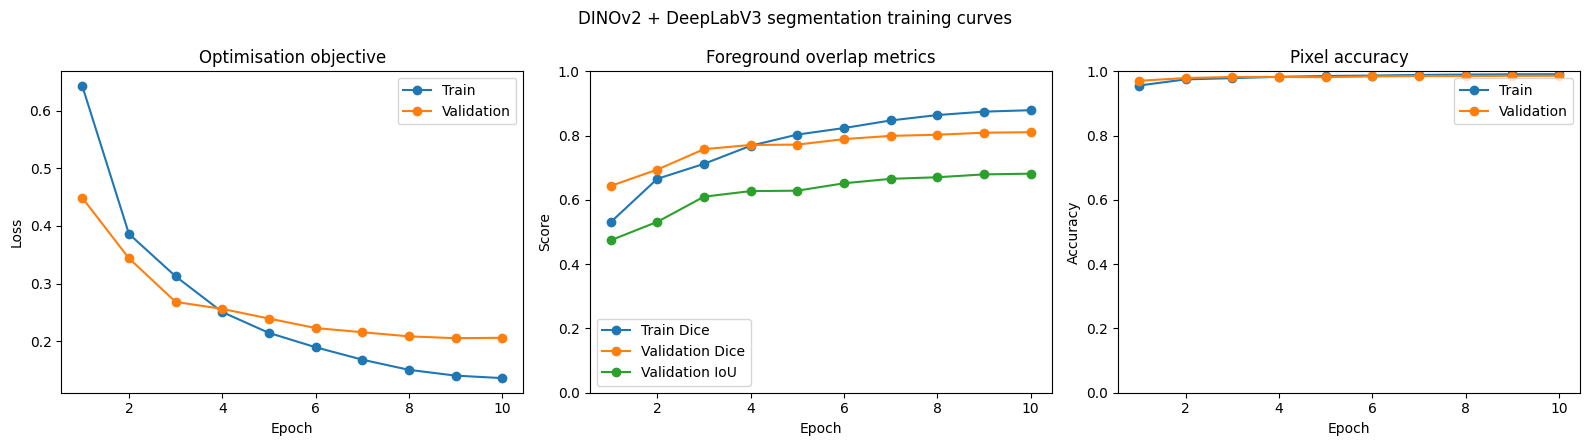

In [13]:
# ---------------------------------------------------------------------------
# Training curve visualisation
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(history_df["epoch"], history_df["train_loss"], marker="o", label="Train")
axes[0].plot(history_df["epoch"], history_df["val_loss"], marker="o", label="Validation")
axes[0].set_title("Optimisation objective")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history_df["epoch"], history_df["train_dice"], marker="o", label="Train Dice")
axes[1].plot(history_df["epoch"], history_df["val_dice"], marker="o", label="Validation Dice")
axes[1].plot(history_df["epoch"], history_df["val_iou"], marker="o", label="Validation IoU")
axes[1].set_title("Foreground overlap metrics")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_ylim(0, 1)
axes[1].legend()

axes[2].plot(history_df["epoch"], history_df["train_pixel_accuracy"], marker="o", label="Train")
axes[2].plot(history_df["epoch"], history_df["val_pixel_accuracy"], marker="o", label="Validation")
axes[2].set_title("Pixel accuracy")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Accuracy")
axes[2].set_ylim(0, 1)
axes[2].legend()

plt.suptitle("DINOv2 + DeepLabV3 segmentation training curves")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "training_curves.png", dpi=220, bbox_inches="tight")
plt.show()

## 10. Test-set evaluation

The best checkpoint is selected using validation Dice only; the test split is used once for final performance reporting. This prevents the test data from influencing model selection.

In [14]:
checkpoint = torch.load(best_checkpoint_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

with torch.inference_mode():
    test_statistics = run_epoch(model, test_loader, training=False)

test_results = pd.DataFrame([{
    "Best validation epoch": checkpoint["epoch"],
    "Test loss": test_statistics["loss"],
    "Test Dice": test_statistics["dice"],
    "Test IoU": test_statistics["iou"],
    "Test pixel accuracy": test_statistics["pixel_accuracy"],
    "DINOv2 initialisation": checkpoint["dinov2_load_status"]
}])
display(test_results)
test_results.to_csv(OUTPUT_DIR / "test_metrics.csv", index=False)

Validation:   0%|          | 0/27 [00:00<?, ?it/s]

,Best validation epoch,Test loss,Test Dice,Test IoU,Test pixel accuracy,DINOv2 initialisation
0,10,0.210246,0.801536,0.668803,0.985282,Pretrained DINOv2 weights downloaded successfu...


## 11. Qualitative interpretation: probability, prediction, overlay, and error map

A hard predicted mask shows the final class assignment, whereas the tumour probability map exposes uncertainty near the boundary. The error map uses distinct categories for missed tumour pixels and excessive foreground prediction, which is more instructive than viewing an overlay alone.

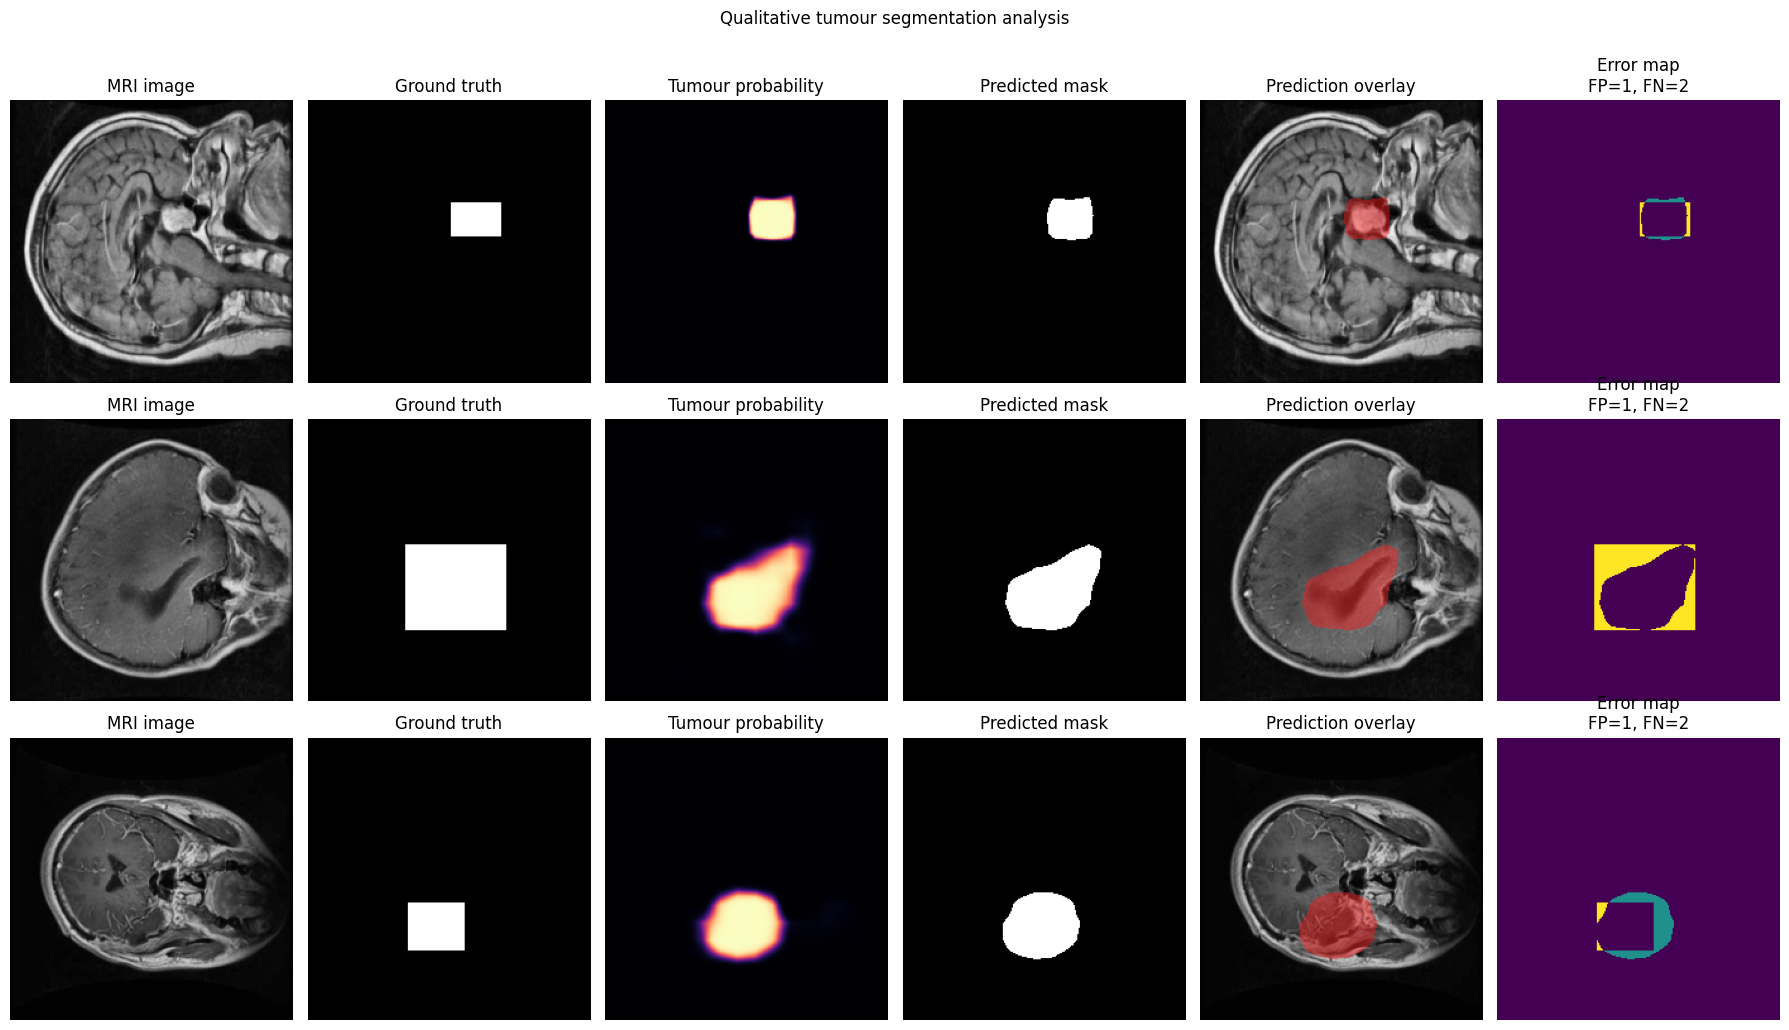

In [15]:
# Normalisation inversion for display of MRI images
DISPLAY_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
DISPLAY_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

def tensor_to_display_image(tensor):
    image = (tensor.cpu() * DISPLAY_STD + DISPLAY_MEAN).clamp(0, 1)
    return image.permute(1, 2, 0).numpy()

def qualitative_predictions(model, dataset, fractions, number_of_examples=3):
    positive_indices = np.where(fractions > 0)[0]
    if len(positive_indices) == 0:
        positive_indices = np.arange(min(number_of_examples, len(dataset)))
    indices = positive_indices[
        np.linspace(0, len(positive_indices) - 1,
                    min(number_of_examples, len(positive_indices)), dtype=int)
    ]

    fig, axes = plt.subplots(len(indices), 6, figsize=(18, 3.4 * len(indices)))
    axes = np.atleast_2d(axes)

    for row, index in enumerate(indices):
        image_tensor, ground_truth = dataset[int(index)]
        input_batch = image_tensor.unsqueeze(0).to(device).contiguous()

        with torch.inference_mode():
            with amp_context():
                logits = model(input_batch)
            probability = torch.softmax(logits.float(), dim=1)[0, 1].cpu().numpy()

        prediction = (probability >= 0.5).astype(np.uint8)
        target = ground_truth.numpy().astype(np.uint8)
        image_np = tensor_to_display_image(image_tensor)

        overlay = image_np.copy()
        overlay[prediction == 1] = (
            0.55 * overlay[prediction == 1] + 0.45 * np.array([1.0, 0.1, 0.1])
        )

        # Error map: 0=correct, 1=false positive, 2=false negative.
        error = np.zeros_like(target)
        error[(prediction == 1) & (target == 0)] = 1
        error[(prediction == 0) & (target == 1)] = 2

        panels = [
            (image_np, "MRI image", None, None),
            (target, "Ground truth", "gray", 1),
            (probability, "Tumour probability", "magma", 1),
            (prediction, "Predicted mask", "gray", 1),
            (overlay, "Prediction overlay", None, None),
            (error, "Error map\nFP=1, FN=2", "viridis", 2),
        ]

        for column, (panel, title, colour_map, vmax) in enumerate(panels):
            axes[row, column].imshow(panel, cmap=colour_map, vmin=0 if colour_map else None, vmax=vmax)
            axes[row, column].set_title(title)
            axes[row, column].axis("off")

    plt.suptitle("Qualitative tumour segmentation analysis", y=1.01)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "qualitative_prediction_panels.png", dpi=220, bbox_inches="tight")
    plt.show()

qualitative_predictions(model, test_dataset, test_fractions, number_of_examples=3)

## 12. Spatial response maps before and after segmentation fine-tuning

The response map below is obtained by averaging the absolute DINOv2 patch-token activations across channels and upsampling the resulting \(16\times16\) grid. It is **not** a predicted tumour mask. Rather, it indicates where the encoder representation places substantial feature energy before and after task-specific fine-tuning.

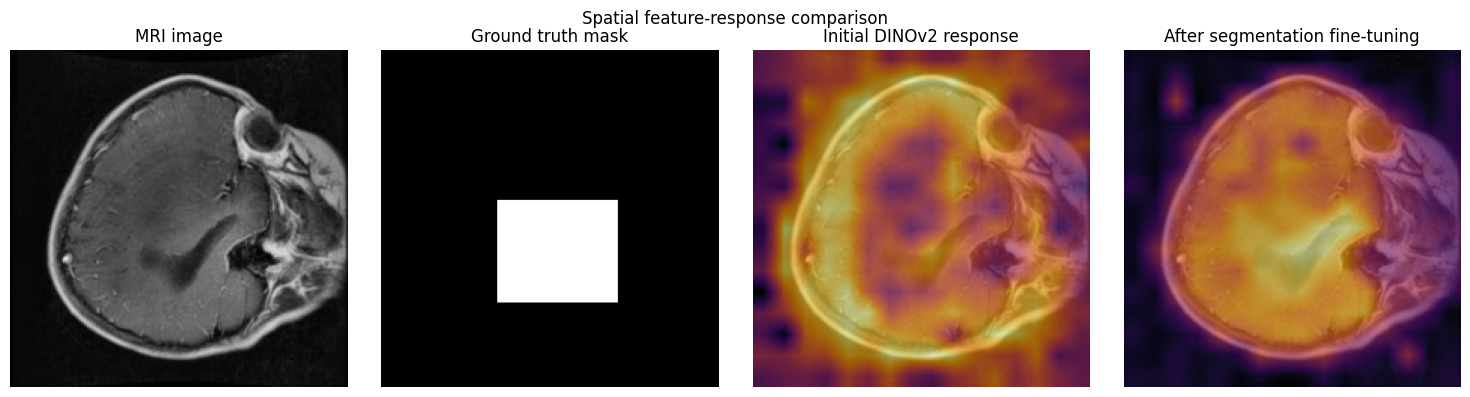

In [16]:
def spatial_response_map(encoder_model, image_tensor, execution_device):
    encoder_model = encoder_model.to(execution_device).eval()
    batch = image_tensor.unsqueeze(0).to(execution_device).contiguous()
    with torch.inference_mode():
        output = encoder_model(pixel_values=batch)
        tokens = output.last_hidden_state[:, 1:, :]
        grid = int(math.sqrt(tokens.shape[1]))
        response = tokens.abs().mean(dim=-1).reshape(1, 1, grid, grid)
        response = F.interpolate(
            response, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False
        )[0, 0]
        response = response.float().cpu().numpy()
    response = (response - response.min()) / (response.max() - response.min() + 1e-8)
    encoder_model.cpu()
    return response

positive_test_indices = np.where(test_fractions > 0)[0]
selected_index = (
    int(positive_test_indices[len(positive_test_indices) // 2])
    if len(positive_test_indices) else 0
)
feature_image, feature_mask = test_dataset[selected_index]

initial_response = spatial_response_map(initial_encoder, feature_image, device)
fine_tuned_response = spatial_response_map(model.encoder, feature_image, device)
model.encoder.to(device)
display_image = tensor_to_display_image(feature_image)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))
axes[0].imshow(display_image)
axes[0].set_title("MRI image")
axes[1].imshow(feature_mask.numpy(), cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Ground truth mask")
axes[2].imshow(display_image)
axes[2].imshow(initial_response, cmap="inferno", alpha=0.62)
axes[2].set_title("Initial DINOv2 response")
axes[3].imshow(display_image)
axes[3].imshow(fine_tuned_response, cmap="inferno", alpha=0.62)
axes[3].set_title("After segmentation fine-tuning")

for axis in axes:
    axis.axis("off")
plt.suptitle("Spatial feature-response comparison")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "spatial_feature_response_maps.png", dpi=220, bbox_inches="tight")
plt.show()

## 13. t-SNE visualisation of the feature space

Each point represents one MRI image embedding obtained by averaging DINOv2 patch tokens. Colour indicates the annotated tumour-area group, not a diagnostic category. The comparison asks whether segmentation fine-tuning changes the representation in relation to the spatial burden of the annotated region.

Extracting DINOv2 embeddings:   0%|          | 0/27 [00:00<?, ?it/s]

Extracting DINOv2 embeddings:   0%|          | 0/27 [00:00<?, ?it/s]

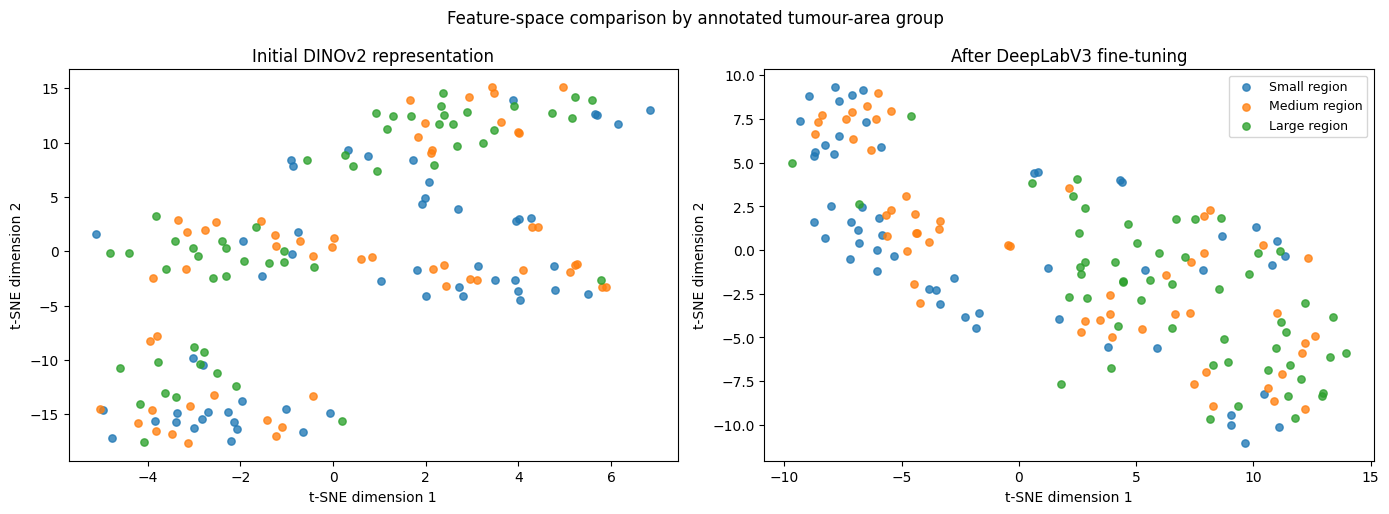

In [17]:
def tumour_area_group(fractions):
    """Create interpretable area categories for t-SNE colouring."""
    positive = fractions[fractions > 0]
    if len(positive) >= 3:
        q1, q2 = np.quantile(positive, [0.33, 0.67])
    else:
        q1, q2 = 0.01, 0.04

    groups = []
    for fraction in fractions:
        if fraction <= 0:
            groups.append("No annotated tumour")
        elif fraction <= q1:
            groups.append("Small region")
        elif fraction <= q2:
            groups.append("Medium region")
        else:
            groups.append("Large region")
    return np.asarray(groups)


def extract_embeddings(encoder_model, loader, maximum_samples=160):
    """Extract global image embeddings by averaging spatial patch tokens."""
    encoder_model = encoder_model.to(device).eval()
    embedding_list = []
    observed = 0

    with torch.inference_mode():
        for images, _ in tqdm(loader, desc="Extracting DINOv2 embeddings", leave=False):
            images = images.to(device, non_blocking=PIN_MEMORY).contiguous()
            with amp_context():
                outputs = encoder_model(pixel_values=images)
            embeddings = outputs.last_hidden_state[:, 1:, :].float().mean(dim=1).cpu().numpy()
            embedding_list.append(embeddings)
            observed += images.shape[0]
            if observed >= maximum_samples:
                break

    encoder_model.cpu()
    return np.concatenate(embedding_list, axis=0)[:maximum_samples]


tsne_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY
)
number_for_tsne = min(160, len(test_dataset))
labels_for_tsne = tumour_area_group(test_fractions[:number_for_tsne])

initial_embeddings = extract_embeddings(initial_encoder, tsne_loader, maximum_samples=number_for_tsne)
fine_tuned_embeddings = extract_embeddings(model.encoder, tsne_loader, maximum_samples=number_for_tsne)
model.encoder.to(device)

if number_for_tsne >= 6:
    perplexity = min(30, max(5, (number_for_tsne - 1) // 3))
    initial_projection = TSNE(
        n_components=2, perplexity=perplexity, init="pca",
        learning_rate="auto", random_state=SEED
    ).fit_transform(initial_embeddings)
    fine_tuned_projection = TSNE(
        n_components=2, perplexity=perplexity, init="pca",
        learning_rate="auto", random_state=SEED
    ).fit_transform(fine_tuned_embeddings)

    categories = ["No annotated tumour", "Small region", "Medium region", "Large region"]
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

    for label in categories:
        selected = labels_for_tsne == label
        if selected.any():
            axes[0].scatter(
                initial_projection[selected, 0], initial_projection[selected, 1],
                s=28, alpha=0.78, label=label
            )
            axes[1].scatter(
                fine_tuned_projection[selected, 0], fine_tuned_projection[selected, 1],
                s=28, alpha=0.78, label=label
            )

    axes[0].set_title("Initial DINOv2 representation")
    axes[1].set_title("After DeepLabV3 fine-tuning")
    for axis in axes:
        axis.set_xlabel("t-SNE dimension 1")
        axis.set_ylabel("t-SNE dimension 2")
    axes[1].legend(loc="best", fontsize=9)

    plt.suptitle("Feature-space comparison by annotated tumour-area group")
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "tsne_feature_space_comparison.png", dpi=220, bbox_inches="tight")
    plt.show()
else:
    print("The test split contains too few images for a meaningful t-SNE visualisation.")

## 14. Interpretation guide for laboratory discussion

1. **Annotation conversion:** the red overlay should correspond to the polygon-defined tumour region. Any mismatch indicates an error in polygon rasterisation or image–annotation association.
2. **Training curves:** Dice and IoU are more informative than pixel accuracy when tumour pixels are sparse. A high accuracy accompanied by weak Dice suggests background-dominant prediction.
3. **Probability map:** uncertain boundary regions should be inspected rather than judged only through a thresholded mask.
4. **Error map:** false negatives indicate missed tumour pixels; false positives indicate over-segmentation.
5. **Spatial response map:** this representation-level view should not be interpreted as a medical explanation or a calibrated localisation map.
6. **t-SNE:** separation or reorganisation after fine-tuning is descriptive evidence about the learned embedding space; it does not prove clinical validity or diagnostic generalisation.

### Files produced by the notebook

The notebook saves:

- `checkpoints/best_dinov2_deeplabv3.pt`;
- `training_history.csv`;
- `test_metrics.csv`;
- dataset-distribution, workflow, training-curve, qualitative-output, spatial-response, and t-SNE figures under the `figures/` directory.

### Closing summary

This exercise treats DINOv2 as a self-supervised visual encoder and DeepLabV3-style ASPP as the dense prediction mechanism. The resulting workflow connects representation learning with semantic mask estimation while keeping the COCO-to-binary-mask conversion, computational safety checks, and interpretation of segmentation evidence explicit.

In [18]:
# ---------------------------------------------------------------------------
# Final record of generated artefacts for convenient Kaggle retrieval
# ---------------------------------------------------------------------------
saved_files = sorted(
    str(path.relative_to(OUTPUT_DIR))
    for path in OUTPUT_DIR.rglob("*")
    if path.is_file()
)
print("Generated output files:")
for file_name in saved_files:
    print(f" - {file_name}")

Generated output files:
 - checkpoints/best_dinov2_deeplabv3.pt
 - figures/annotation_examples.png
 - figures/dinov2_deeplabv3_workflow.png
 - figures/mask_area_distribution.png
 - figures/qualitative_prediction_panels.png
 - figures/spatial_feature_response_maps.png
 - figures/training_curves.png
 - figures/tsne_feature_space_comparison.png
 - test_metrics.csv
 - training_history.csv
